In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [5]:
image = cv2.imread('sar_2_color.jpg')

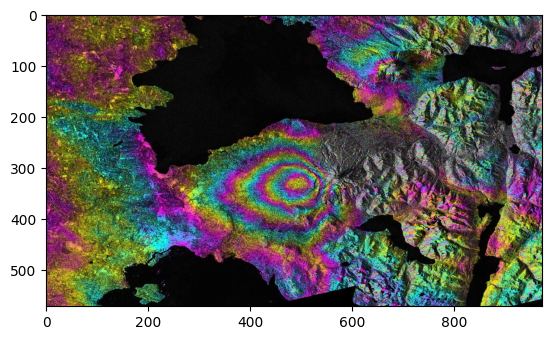

In [6]:
plt.imshow(image)

In [7]:
image.shape # h,w,c

(572, 974, 3)

In [8]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [9]:
# ROI
img_roi = image[100:200, 500:700]

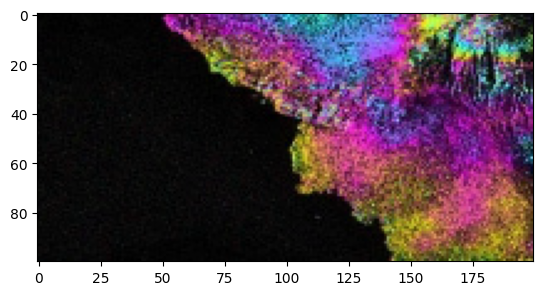

In [10]:
plt.imshow(img_roi)

In [11]:
b,g,r = cv2.split(image)

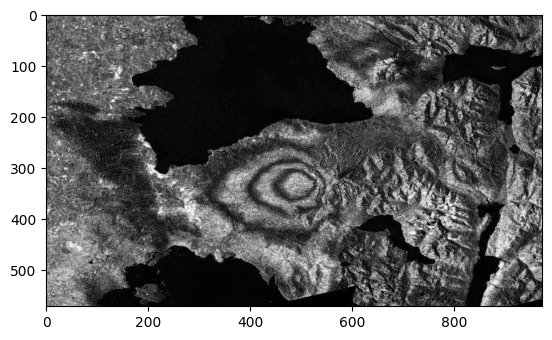

In [12]:
plt.imshow(b, cmap = 'gray')

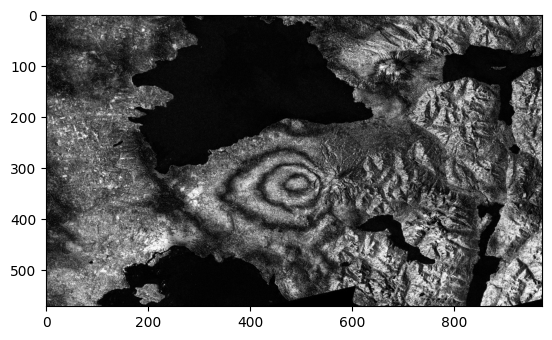

In [13]:
plt.imshow(g, cmap = 'gray')

In [14]:
# alternative approach
b = image[:,:,0]

In [15]:
import copy

image2 = copy.deepcopy(image)

In [16]:
image2[50:100,50:100] = [0,0,0]

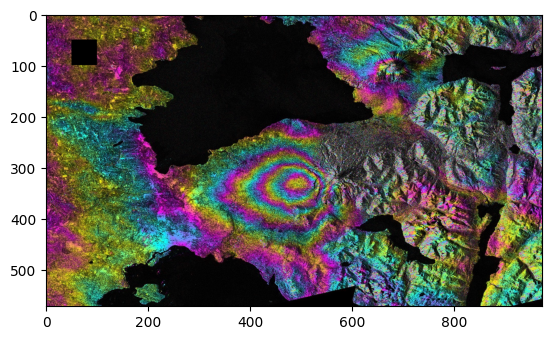

In [17]:
plt.imshow(image2)

In [18]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

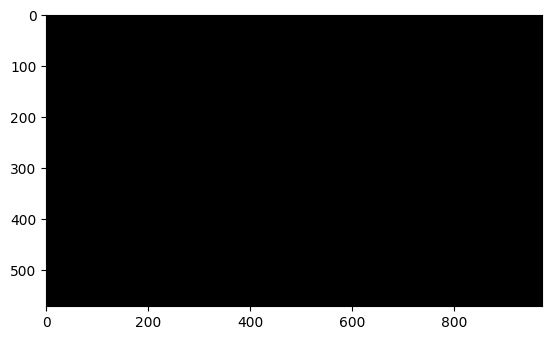

In [19]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [20]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [21]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [22]:
image_gray[0,0]

np.uint8(40)

In [23]:
image_gray.shape

(572, 974)

In [24]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [25]:
image_hsv.shape

(572, 974, 3)

In [26]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [27]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [28]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [29]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [30]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

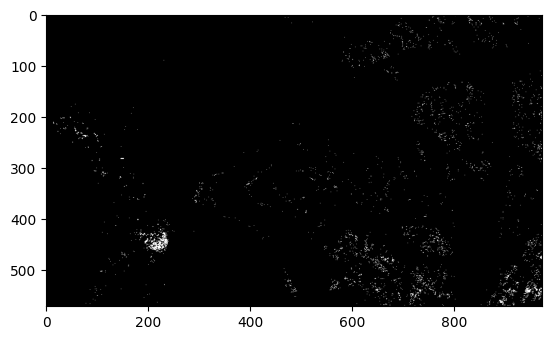

In [31]:
plt.imshow(thresh1, cmap='gray')

In [32]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [33]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

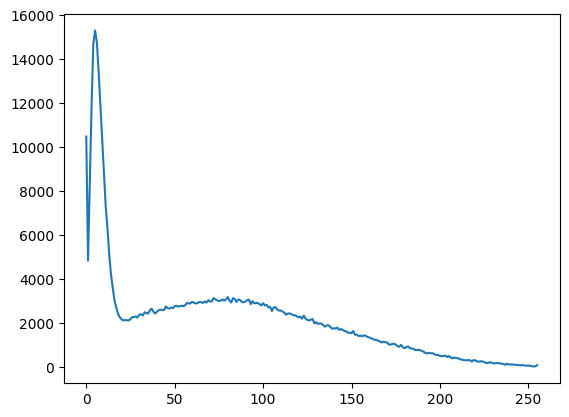

In [34]:
plt.plot(b_hist)

In [35]:
b_hist_cum = b_hist.cumsum()

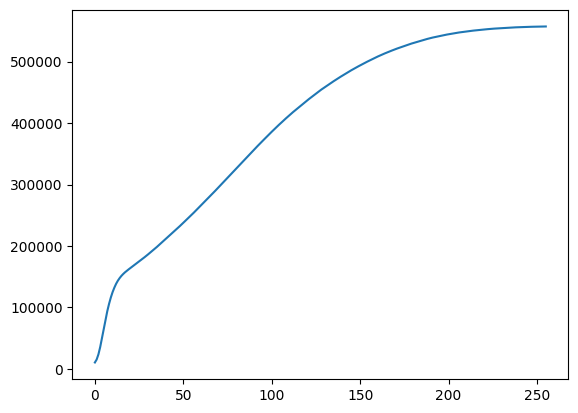

In [36]:
plt.plot(b_hist_cum)

In [37]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

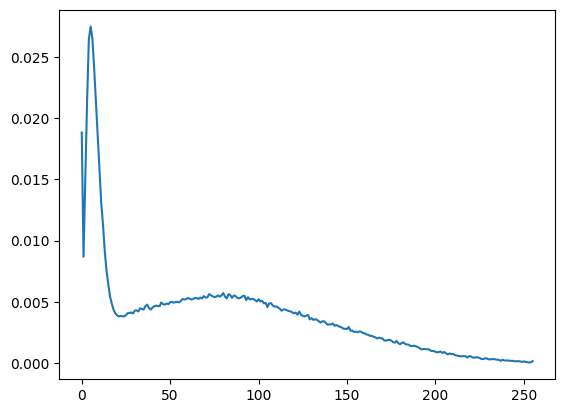

In [38]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [39]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


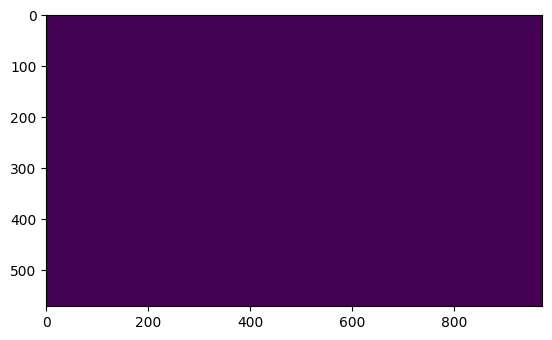

In [40]:
plt.imshow(diff)

In [41]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [42]:
mean = image_gray.mean()

In [43]:
std = image_gray.std()

In [44]:
print(mean,std)

67.41225535245043 52.016191875959635


In [45]:
eq_gray = cv2.equalizeHist(image_gray)

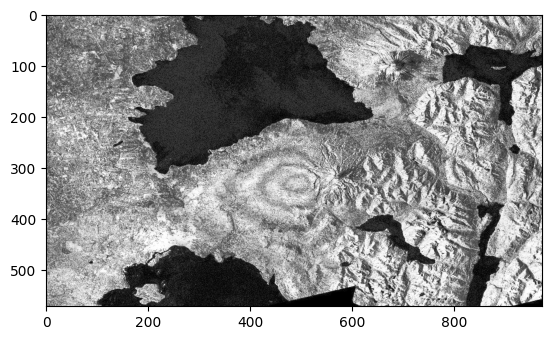

In [46]:
plt.imshow(eq_gray, cmap="gray")


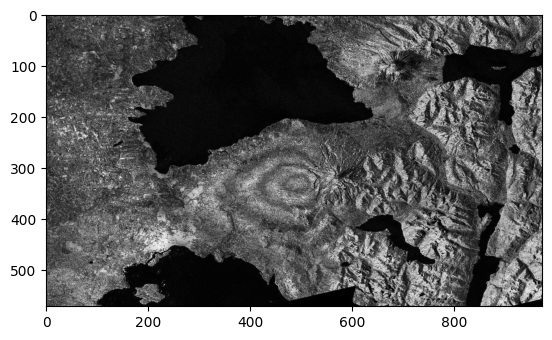

In [47]:
plt.imshow(image_gray, cmap="gray")

In [49]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


Размер (400, 600)
Тип данных: uint8
Мин. яркость: 0  Макс. яркость: 255


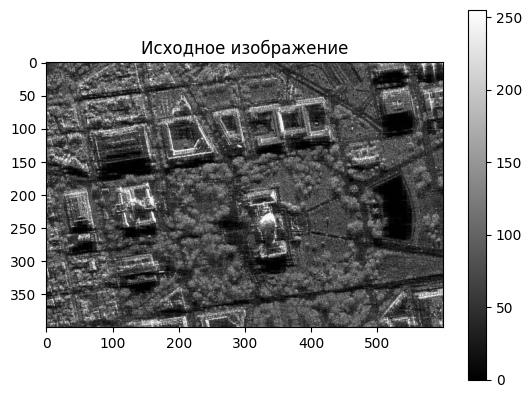

In [55]:
#1 задание

img = cv2.imread('sar_1_gray.jpg',cv2.IMREAD_GRAYSCALE) #Загружаем серую картинку
print('Размер', img.shape)
print('Тип данных:', img.dtype)
print('Мин. яркость:', img.min(), ' Макс. яркость:', img.max())

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение')
plt.colorbar()
plt.show()

Сумма столбикам: 240000.0 = 240000


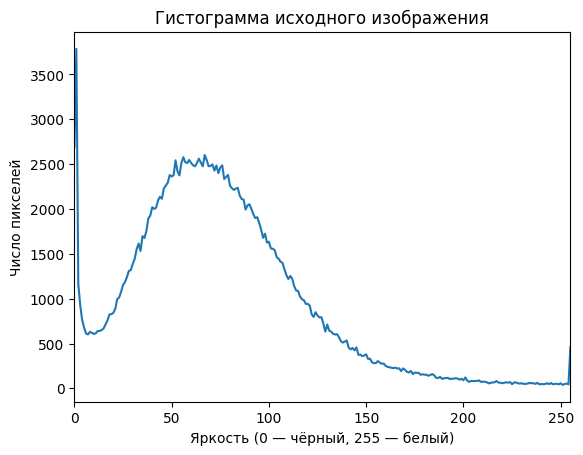

In [58]:
hist = cv2.calcHist([img], [0], None, [256], (0, 256))

print('Сумма столбикам:', hist.sum(), '=', img.shape[0] * img.shape[1])

plt.plot(hist)
plt.title('Гистограмма исходного изображения')
plt.xlabel('Яркость (0 — чёрный, 255 — белый)')
plt.ylabel('Число пикселей')
plt.xlim(0, 255)
plt.show()

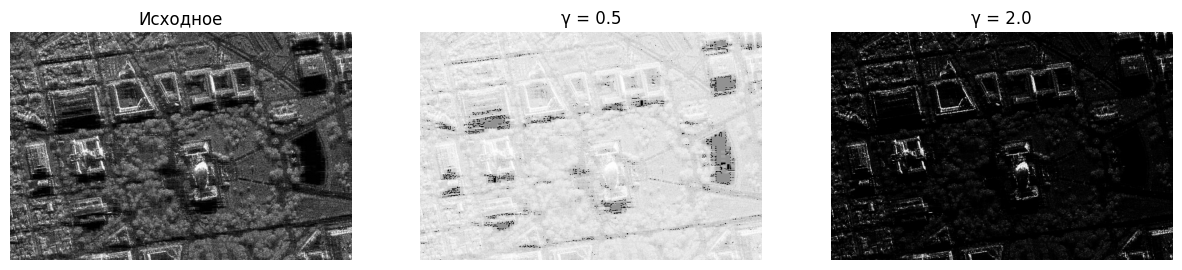

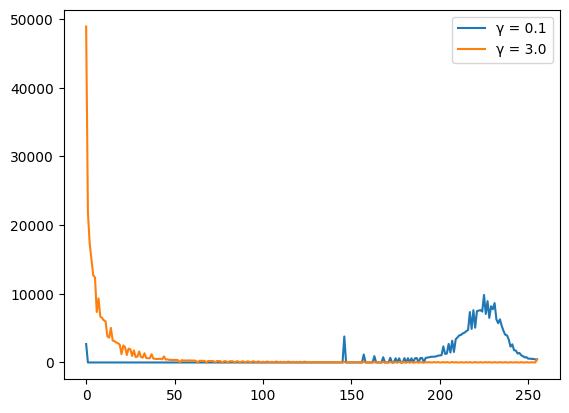

In [65]:
def gamma_correction(image, gamma):
    table = np.array([255 * (i / 255) ** gamma for i in range(256)]).astype(np.uint8)
    return cv2.LUT(image, table)

img_g05 = gamma_correction(img, 0.1)
img_g20 = gamma_correction(img, 3.0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [img, img_g05, img_g20], ['Исходное', 'γ = 0.1', 'γ = 3.0']):
    a.imshow(im, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.show()


for im, t in [(img_g05, 'γ = 0.1'), (img_g20, 'γ = 3.0')]:
    plt.plot(cv2.calcHist([im], [0], None, [256], (0, 256)), label=t)
plt.legend(); plt.show()

In [66]:
for name, im in [('γ = 0.1', img_g05), ('γ = 3.0', img_g20)]:
    ssim = structural_similarity(img, im)
    mse = mean_squared_error(img, im)
    print(f'{name}: SSIM = {ssim:.4f}, MSE = {mse:.2f}')

γ = 0.1: SSIM = 0.3248, MSE = 21665.04
γ = 3.0: SSIM = 0.2109, MSE = 4424.04


Исходное  : mean =  74.94, std =  43.66
eq_gray   : mean = 127.03, std =  74.27
Результат : mean = 123.12, std =  65.30


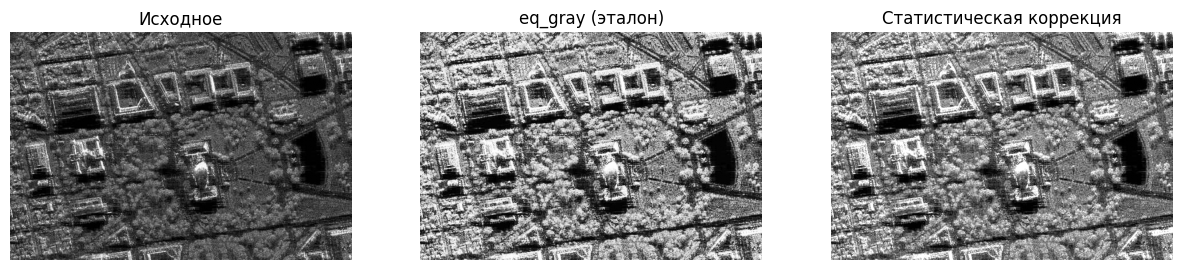

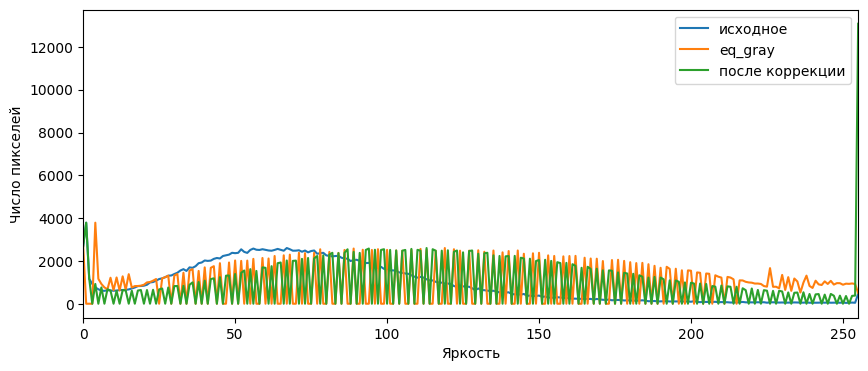

Сравнение с исходного: SSIM = 0.7862, MSE = 2946.70
Сравнение с eq_gray: SSIM = 0.9500, MSE = 247.70


In [73]:
eq_gray = cv2.equalizeHist(img)

def stat_correction(src, ref):
    src_f = src.astype(np.float32)          # переходим к float, чтобы не было переполнения uint8
    mu_src, std_src = src_f.mean(), src_f.std()
    mu_ref, std_ref = ref.mean(), ref.std()

    out = (src_f - mu_src) / std_src * std_ref + mu_ref
    return np.clip(out, 0, 255).astype(np.uint8)   # обрезаем до 0–255 и возвращаем uint8

img_stat = stat_correction(img, eq_gray)
print(f'Исходное  : mean = {img.mean():6.2f}, std = {img.std():6.2f}')
print(f'eq_gray   : mean = {eq_gray.mean():6.2f}, std = {eq_gray.std():6.2f}')
print(f'Результат : mean = {img_stat.mean():6.2f}, std = {img_stat.std():6.2f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [img, eq_gray, img_stat],
                    ['Исходное', 'eq_gray (эталон)', 'Статистическая коррекция']):
    a.imshow(im, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.show()


plt.figure(figsize=(10, 4))
for im, t in [(img, 'исходное'), (eq_gray, 'eq_gray'), (img_stat, 'после коррекции')]:
    plt.plot(cv2.calcHist([im], [0], None, [256], (0, 256)), label=t)
plt.legend(); plt.xlim(0, 255); plt.xlabel('Яркость'); plt.ylabel('Число пикселей')
plt.show()


for name, ref in [('исходного', img), ('eq_gray', eq_gray)]:
    print(f'Сравнение с {name}: '
          f'SSIM = {structural_similarity(ref, img_stat, data_range=255):.4f}, '
          f'MSE = {mean_squared_error(ref, img_stat):.2f}')

T =  50: белых пикселей  70.5%
T = 100: белых пикселей  23.2%
T = 150: белых пикселей   5.5%
T = 200: белых пикселей   1.6%


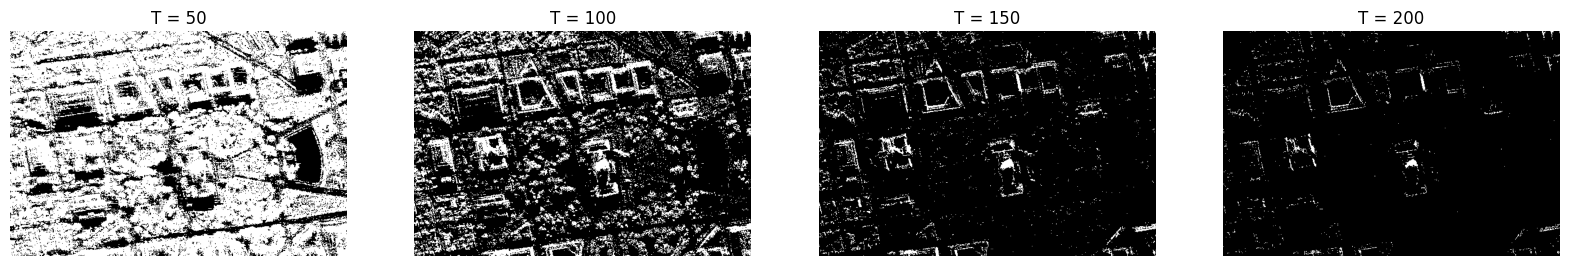

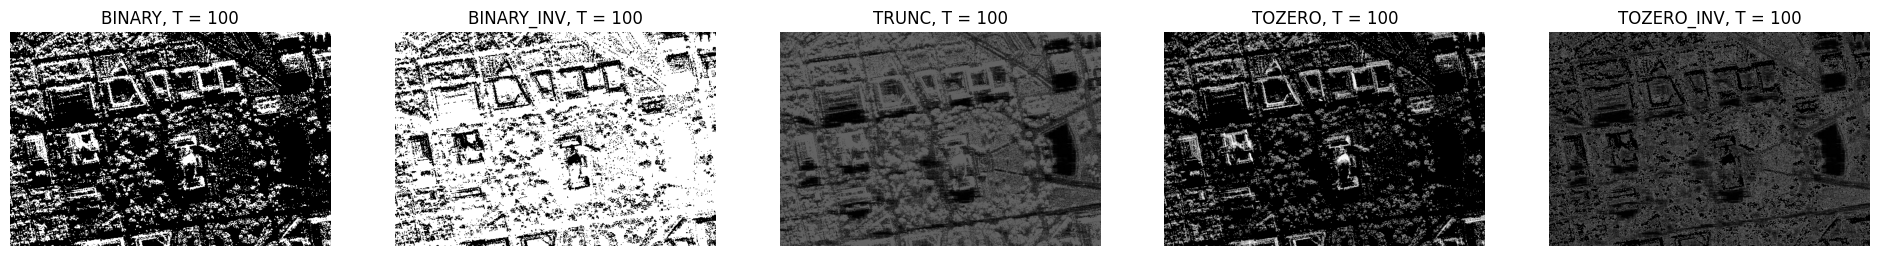

Порог Оцу: 85.0, белых пикселей 35.0%


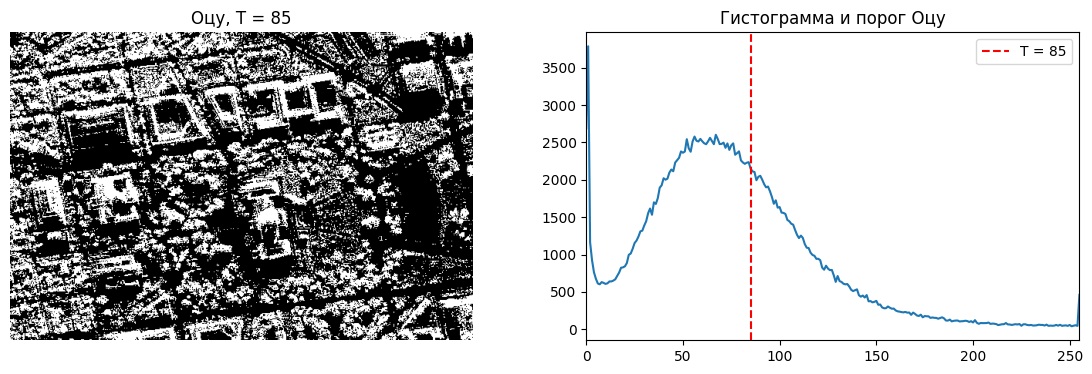

blockSize=11, C= 2: белых пикселей  49.1%
blockSize=11, C=10: белых пикселей  65.9%
blockSize=31, C= 2: белых пикселей  45.9%
blockSize=31, C=10: белых пикселей  58.5%


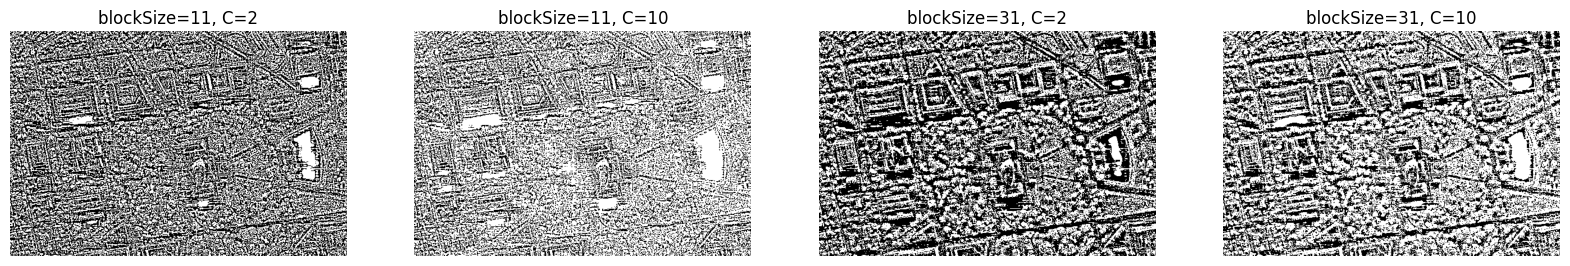

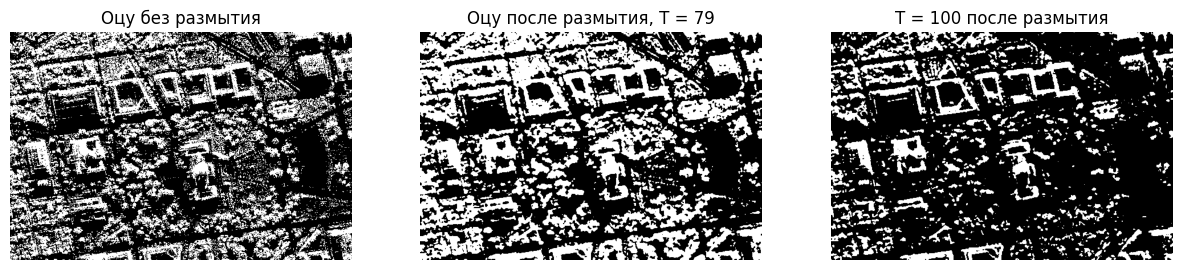

In [74]:
thresholds = [50, 100, 150, 200]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, t in zip(axes, thresholds):
    _, res = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    share = (res == 255).mean() * 100
    ax.imshow(res, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'T = {t}')
    ax.axis('off')
    print(f'T = {t:>3}: белых пикселей {share:5.1f}%')
plt.show()
types = {
    'BINARY':      cv2.THRESH_BINARY,
    'BINARY_INV':  cv2.THRESH_BINARY_INV,
    'TRUNC':       cv2.THRESH_TRUNC,
    'TOZERO':      cv2.THRESH_TOZERO,
    'TOZERO_INV':  cv2.THRESH_TOZERO_INV,
}

T = 100
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for ax, (name, flag) in zip(axes, types.items()):
    _, res = cv2.threshold(img, T, 255, flag)
    ax.imshow(res, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{name}, T = {T}')
    ax.axis('off')
plt.show()
t_otsu, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Порог Оцу: {t_otsu}, белых пикселей {(otsu == 255).mean() * 100:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(otsu, cmap='gray'); ax[0].set_title(f'Оцу, T = {t_otsu:.0f}'); ax[0].axis('off')
ax[1].plot(cv2.calcHist([img], [0], None, [256], (0, 256)))
ax[1].axvline(t_otsu, color='r', linestyle='--', label=f'T = {t_otsu:.0f}')
ax[1].set_xlim(0, 255); ax[1].legend(); ax[1].set_title('Гистограмма и  Оцу')
plt.show()
params = [(11, 2), (11, 10), (31, 2), (31, 10)]   # (blockSize, C)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (block, C) in zip(axes, params):
    res = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, block, C)
    ax.imshow(res, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'blockSize={block}, C={C}')
    ax.axis('off')
    print(f'blockSize={block:>2}, C={C:>2}: белых пикселей {(res == 255).mean() * 100:5.1f}%')
plt.show()
blur = cv2.GaussianBlur(img, (5, 5), 0)

t_b, otsu_blur = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, thr_blur = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [otsu, otsu_blur, thr_blur],
                    ['Оцу без размытия', f'Оцу после размытия, T = {t_b:.0f}', 'T = 100 после размытия']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.show()